In [28]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import KFold
import random


In [29]:
df =  pd.read_csv("Housing.csv")
copy = df.copy()

copy.info()


<class 'pandas.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             550 non-null    int64  
 1   area              547 non-null    float64
 2   bedrooms          550 non-null    int64  
 3   bathrooms         550 non-null    int64  
 4   stories           550 non-null    int64  
 5   mainroad          550 non-null    str    
 6   guestroom         550 non-null    str    
 7   basement          550 non-null    str    
 8   hotwaterheating   550 non-null    str    
 9   airconditioning   550 non-null    str    
 10  parking           550 non-null    int64  
 11  prefarea          550 non-null    str    
 12  furnishingstatus  546 non-null    str    
dtypes: float64(1), int64(5), str(7)
memory usage: 56.0 KB


In [30]:
print("Null Data before filling NULL....")
print(copy.isna().sum())

print()

print("Duplicated data before romoving the duplicates..")
print(copy.duplicated().sum())

Null Data before filling NULL....
price               0
area                3
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    4
dtype: int64

Duplicated data before romoving the duplicates..
5


In [31]:
objcols = copy.select_dtypes(include=['object','string']).columns
numcols = copy.select_dtypes(include='number').columns

copy[numcols]=copy[numcols].apply(pd.to_numeric,errors='coerce')
copy[numcols]=copy[numcols].fillna(copy[numcols].mean())
copy[objcols]=copy[objcols].fillna(copy[objcols].mode().iloc[0])


print("Null Data after filling null: ")
print(copy.isna().sum())

print()

copy=copy.drop_duplicates(keep='first')
print(f"Duplicated data after before removing the duplicates: {copy.duplicated().sum()}")


Null Data after filling null: 
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicated data after before removing the duplicates: 0


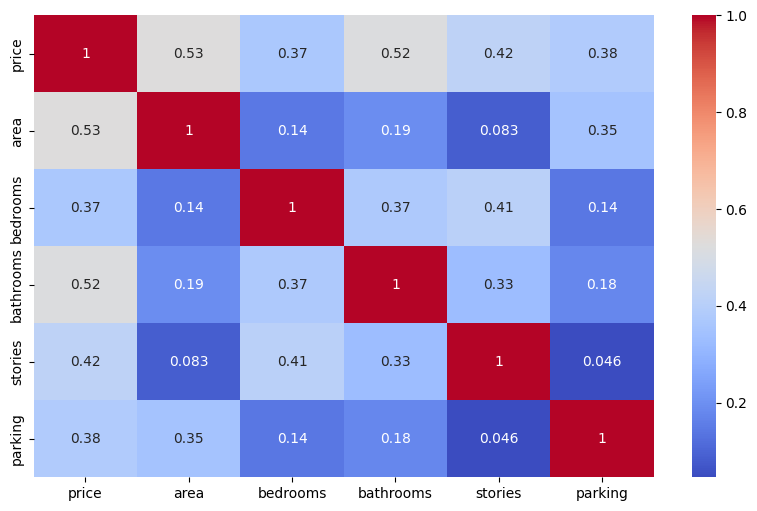

In [32]:
numdata =  copy.select_dtypes(include='number')

plt.figure(figsize=(10,6))
sns.heatmap(numdata.corr(),annot=True,cmap='coolwarm')
plt.show()

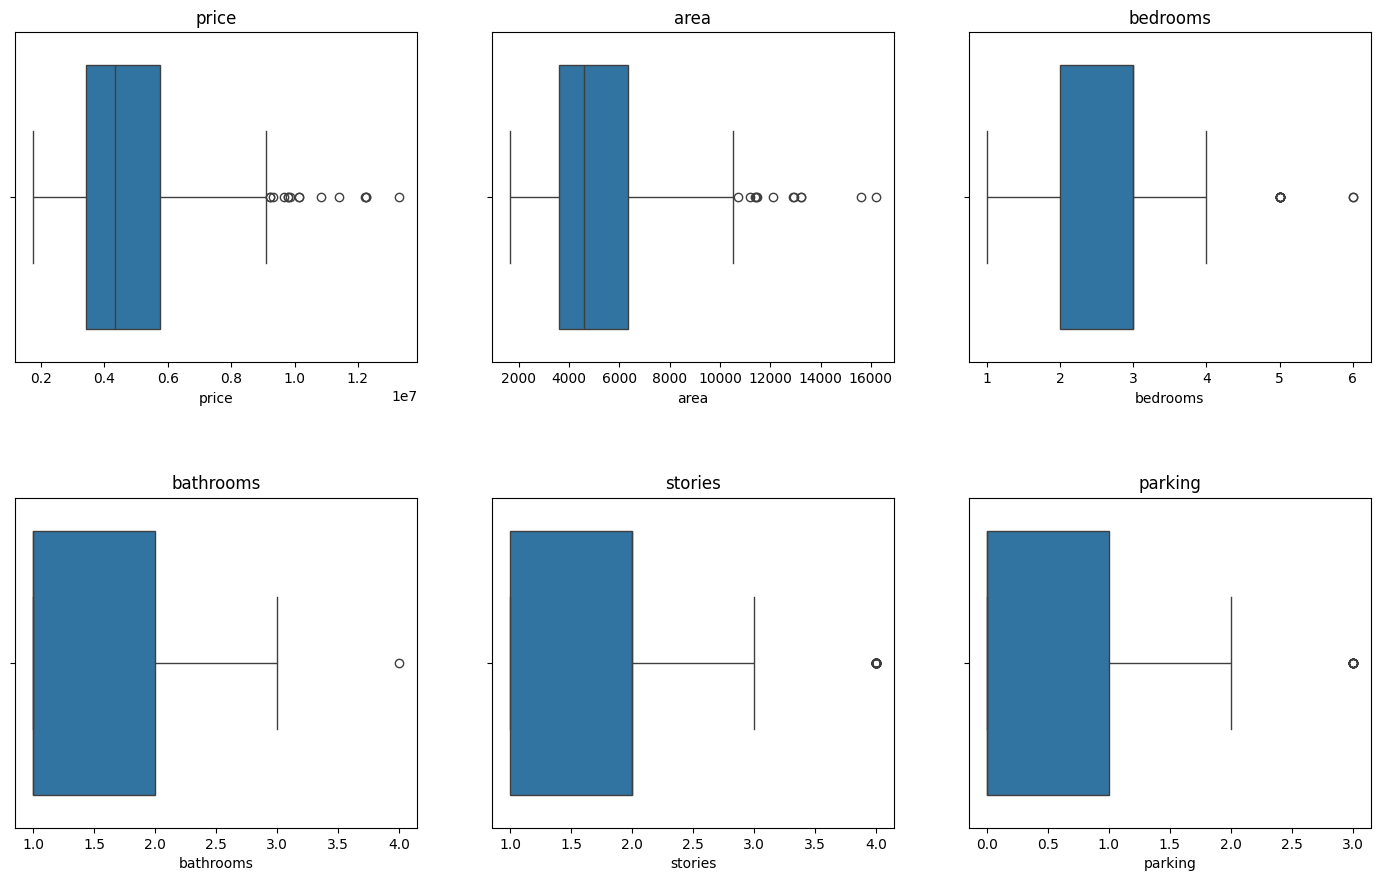

In [33]:
n=len(numcols)
cols=3

rows = (n // cols) + (n % 2 >0)
fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()
for i, col in enumerate(numcols):
    sns.boxplot(x=copy[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout(pad=5)
plt.show()

In [34]:
le = LabelEncoder()
copy['mainroad']=le.fit_transform(copy['mainroad'])
copy['guestroom']=le.fit_transform(copy['guestroom'])
copy['basement']=le.fit_transform(copy['basement'])
copy['hotwaterheating']=le.fit_transform(copy['hotwaterheating'])
copy['airconditioning']=le.fit_transform(copy['airconditioning'])
copy['prefarea']=le.fit_transform(copy['prefarea'])

pd.options.display.max_columns=None

copy = pd.get_dummies(copy,columns=['furnishingstatus'],drop_first=True)

bool_cols = copy.select_dtypes(include='bool').columns 
copy[bool_cols] = copy[bool_cols].astype(int)
copy.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420.0,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960.0,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960.0,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500.0,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420.0,4,1,2,1,1,1,0,1,2,0,0,0


In [35]:
scaler = StandardScaler()
y=copy.pop('price')
x=copy
scaler.fit(x)
x=scaler.transform(x)
x = pd.DataFrame(x,columns=copy.columns)

kf = KFold(n_splits=5,shuffle=True,random_state=random.randint(1,100))
model = LinearRegression()
r2_scores = []
mae = []
rmse = []

for trainindex,testindex in kf.split(x):
    xtrain,xtest=x.iloc[trainindex],x.iloc[testindex]
    ytrain,ytest=y.iloc[trainindex],y.iloc[testindex]
    model.fit(xtrain,ytrain)
    ypred=model.predict(xtest)
    r2_scores.append(r2_score(ytest,ypred))
    mae.append(mean_absolute_error(ytest,ypred))
    rmse.append(root_mean_squared_error(ytest,ypred))


for i in range(0,len(r2_scores)):
    print(f"R2 Score in iteration {i+1}: {r2_scores[i]}")
    print(f"Mean absolute error in iteration {i+1}: {mae[i]}")
    print(f"Root mean squared error in iteration {i+1}: {rmse[i]}")
    print()

print(f"R2 mean: {np.mean(r2_scores)}")
print(f"Mean absolute error: {np.mean(mae)}")
print(f"Root mean squared error: {np.mean(rmse)}")



R2 Score in iteration 1: 0.6498312302568812
Mean absolute error in iteration 1: 739809.0847767581
Root mean squared error in iteration 1: 942123.600648179

R2 Score in iteration 2: 0.722523670553151
Mean absolute error in iteration 2: 741118.7654800287
Root mean squared error in iteration 2: 944881.8937113757

R2 Score in iteration 3: 0.6017036832417937
Mean absolute error in iteration 3: 941487.7505556103
Root mean squared error in iteration 3: 1311341.7812335128

R2 Score in iteration 4: 0.6173846291883747
Mean absolute error in iteration 4: 825058.5834951145
Root mean squared error in iteration 4: 1099602.3678887046

R2 Score in iteration 5: 0.6615794799065975
Mean absolute error in iteration 5: 805177.7126438784
Root mean squared error in iteration 5: 1192429.0294056183

R2 mean: 0.6506045386293596
Mean absolute error: 810530.379390278
Root mean squared error: 1098075.7345774781


In [36]:
print("Pridict your house price")

area = int(input("Enter the area of the house: "))
bedrooms = int(input("Enter the bedrooms: "))
bathrooms = int(input("Enter the bathrooms: "))
stories = int(input("Enter the stories: "))
mainroad = int(input("Is it on mainroad(1:YES,0:NO): "))
guestroom = int(input("Does it have guestroom(1:YES,0:NO): "))
basement = int(input("Does it have a basement(1:YES,0:NO): "))
hotwaterheating = int(input("Does it have hotwaterheating(1:YES,0:NO): "))
airconditioning = int(input("Is it airconditioned(1:YES,0:NO): "))
parking = int(input("How much parking space: "))
prefarea = int(input("Does it prefarea(1:YES,0:NO): "))
furnishingstatus = input("How much is it furnished(furnished/semifurnished/unfurnished): ")

newxtest = pd.DataFrame([{
    "area":area,
    "bedrooms":bedrooms,
    "bathrooms": bathrooms,
    "stories": stories,
    "mainroad": mainroad,
    "guestroom": guestroom,
    "basement": basement,
    "hotwaterheating": hotwaterheating,
    "airconditioning": airconditioning,
    "parking": parking,
    "prefarea": prefarea,
    "furnishingstatus_semi-furnished": 0,
    "furnishingstatus_unfurnished":0,
}])

if furnishingstatus.lower()=="semifurnished":
    newxtest['furnishingstatus_semi-furnished'] = 1
elif furnishingstatus.lower()=="unfurnished":
    newxtest["furnishingstatus_unfurnished"] = 1
newxtest=newxtest.reindex(columns=x.columns,fill_value=0)

newxtest = pd.DataFrame(
    scaler.transform(newxtest),
    columns=x.columns
)

print(f"\nPRICE: {model.predict(newxtest)[0]}")

Pridict your house price

PRICE: 7088337.877535676
